# 📊 Data Wrangling II - Student Performance Dataset

## Objective
To preprocess student performance data by:
- Handling missing values and inconsistencies  
- Detecting and treating outliers  
- Applying data transformations for better analysis  

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df=pd.read_csv("Student Performance new.csv")

In [85]:
df

,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,4,group C,some college,standard,none,0.76,0.78,0.75,M
...,...,...,...,...,...,...,...,...,...
995,995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,998,group D,some college,standard,completed,0.68,0.78,0.77,F


The dataset contains 1000 student records with attributes like gender, race, parental education, lunch type, and test scores.

In [86]:
df.head()

,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,4,group C,some college,standard,none,0.76,0.78,0.75,M


In [87]:
df.tail()

,Unnamed: 0,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
995,995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,998,group D,some college,standard,completed,0.68,0.78,0.77,F
999,999,group D,some college,free/reduced,none,0.77,0.86,0.86,F


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1000 non-null   int64  
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math percentage              1000 non-null   float64
 6   reading score percentage     1000 non-null   float64
 7   writing score percentage     1000 non-null   float64
 8   sex                          1000 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [89]:
df.describe()

,Unnamed: 0,math percentage,reading score percentage,writing score percentage
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,0.660890,0.691690,0.680540
std,288.819436,0.151631,0.146002,0.151957
min,0.000000,0.000000,0.170000,0.100000
25%,249.750000,0.570000,0.590000,0.577500
50%,499.500000,0.660000,0.700000,0.690000
75%,749.250000,0.770000,0.790000,0.790000
max,999.000000,1.000000,1.000000,1.000000


### 🔹 Observation
- Dataset has 1000 rows and 9 columns  
- Contains both categorical and numerical features  

In [90]:
df.drop(columns=['Unnamed: 0'], inplace=True)

The 'Unnamed: 0' column is an index column and is removed as it is not useful.

In [91]:
df.isnull()

,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [92]:
df.isnull().sum()

race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math percentage                0
reading score percentage       0
writing score percentage       0
sex                            0
dtype: int64

No missing values found in the dataset.

In [93]:
df.shape

(1000, 8)

In [94]:
df.columns

Index(['race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math percentage',
       'reading score percentage', 'writing score percentage', 'sex'],
      dtype='object')

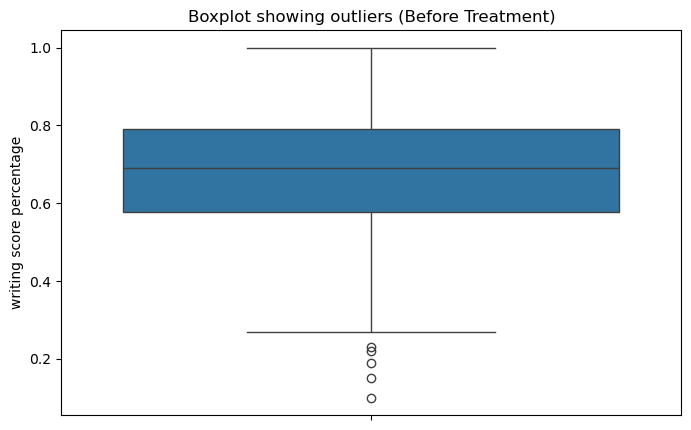

In [95]:
#Box plot:

plt.figure(figsize=(8,5))
sns.boxplot(data=df["writing score percentage"])
plt.title("Boxplot showing outliers (Before Treatment)")
plt.xticks(rotation=45)
plt.show()

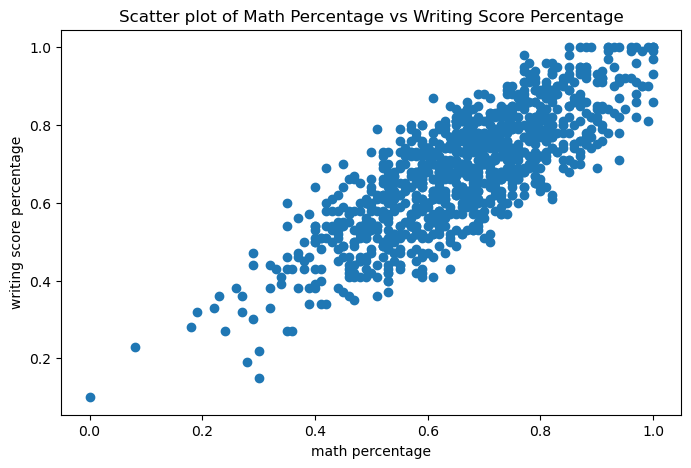

In [96]:
#Scatter plot:

plt.figure(figsize=(8,5))
plt.scatter(df["math percentage"],df["writing score percentage"])
plt.title("Scatter plot of Math Percentage vs Writing Score Percentage")
plt.xlabel("math percentage")
plt.ylabel("writing score percentage")
plt.show()

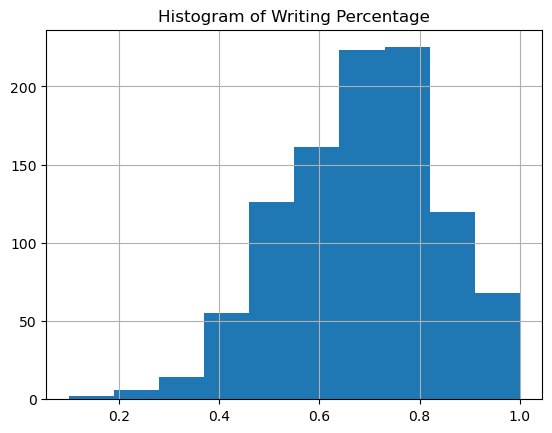

In [97]:
#Histogram:

df["writing score percentage"].hist()
plt.title("Histogram of Writing Percentage")
plt.show()

In [98]:
df["writing score percentage"]=df["writing score percentage"].fillna(df["writing score percentage"].mean())

In [99]:
df

,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,group C,some college,standard,none,0.76,0.78,0.75,M
...,...,...,...,...,...,...,...,...
995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,group D,some college,standard,completed,0.68,0.78,0.77,F


In [100]:
df["lunch"]=df["lunch"].str.strip()

In [101]:
df

,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex
0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,group C,some college,standard,none,0.76,0.78,0.75,M
...,...,...,...,...,...,...,...,...
995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,group D,some college,standard,completed,0.68,0.78,0.77,F


In [102]:
#Outliers:

q1 = df["math percentage"].quantile(0.25)
q3 = df["math percentage"].quantile(0.75)

IQR = q3 - q1

lower = q1 - 1.5*IQR
upper = q3 + 1.5*IQR

print(lower, upper)

outlier = df[(df["math percentage"]<lower) | (df["math percentage"]>upper)]

print(outlier)

0.26999999999999985 1.07
    race/ethnicity parental level of education         lunch  \
17         group B            some high school  free/reduced   
59         group C            some high school  free/reduced   
145        group C                some college  free/reduced   
338        group B            some high school  free/reduced   
466        group D          associate's degree  free/reduced   
787        group B                some college      standard   
842        group B                 high school  free/reduced   
980        group B                 high school  free/reduced   

    test preparation course  math percentage  reading score percentage  \
17                     none             0.18                      0.32   
59                     none             0.00                      0.17   
145                    none             0.22                      0.39   
338                    none             0.24                      0.38   
466                    none 

### 🔹 Observation
Outliers are visible in student score columns.

In [103]:
#Data transformation(min-max scaling):

df["math normalized"] = (df["math percentage"] - df["math percentage"].mean()) / (df["math percentage"].max() - df["math percentage"].min())

Normalization is applied to scale score values between 0 and 1.

In [104]:
df

,race/ethnicity,parental level of education,lunch,test preparation course,math percentage,reading score percentage,writing score percentage,sex,math normalized
0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F,0.05911
1,group C,some college,standard,completed,0.69,0.90,0.88,F,0.02911
2,group B,master's degree,standard,none,0.90,0.95,0.93,F,0.23911
3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M,-0.19089
4,group C,some college,standard,none,0.76,0.78,0.75,M,0.09911
...,...,...,...,...,...,...,...,...,...
995,group E,master's degree,standard,completed,0.88,0.99,0.95,F,0.21911
996,group C,high school,free/reduced,none,0.62,0.55,0.55,M,-0.04089
997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F,-0.07089
998,group D,some college,standard,completed,0.68,0.78,0.77,F,0.01911


In [105]:
df = pd.get_dummies(df, drop_first=True)

Categorical variables are converted into numerical format using one-hot encoding.

In [106]:
df.head()

,math percentage,reading score percentage,writing score percentage,math normalized,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,sex_M
0,0.72,0.72,0.74,0.05911,True,False,False,False,True,False,False,False,False,True,True,False
1,0.69,0.90,0.88,0.02911,False,True,False,False,False,False,False,True,False,True,False,False
2,0.90,0.95,0.93,0.23911,True,False,False,False,False,False,True,False,False,True,True,False
3,0.47,0.57,0.44,-0.19089,False,False,False,False,False,False,False,False,False,False,True,True
4,0.76,0.78,0.75,0.09911,False,True,False,False,False,False,False,True,False,True,True,True


In [107]:
print("first 5 rows:\n", df.head())
print("\n Data info:\n")
df.info()
print("\n statistical summary: \n", df.describe())
print("\n missing values:\n",df.isnull().sum())

first 5 rows:
    math percentage  reading score percentage  writing score percentage  \
0             0.72                      0.72                      0.74   
1             0.69                      0.90                      0.88   
2             0.90                      0.95                      0.93   
3             0.47                      0.57                      0.44   
4             0.76                      0.78                      0.75   

   math normalized  race/ethnicity_group B  race/ethnicity_group C  \
0          0.05911                    True                   False   
1          0.02911                   False                    True   
2          0.23911                    True                   False   
3         -0.19089                   False                   False   
4          0.09911                   False                    True   

   race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False   
1            